# Prediksjonsintervaller ((5) fra Gudmund)

## Assumptions

We assume that the data are generated from a two-state hidden Markov model with state-dependent AR(1) dynamics. Conditional on the hidden state, the one-step innovation is Gaussian with mean zero and state-specific standard deviation.

For the single AR(1) benchmark, we assume a common linear AR(1) structure across the full sample. For the HMM-based forecasts, we estimate the model on the training sample and produce one-step-ahead predictions on the test sample using either a hard state classification or a probability-weighted mixture of states.

Prediction intervals are constructed under Gaussian assumptions. For the mixture forecast, we use the mean and variance of the implied Gaussian mixture to form an approximate normal prediction interval.


## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.hmm_ar_1_k_states import simulate_rs_ar1
from methods.hmm_utils import (
    fit_single_ar1, predict_single_ar1,
    fit_hmm_robust, predict_hmm_hard, predict_hmm_mixture,
    compute_rmse, empirical_coverage, average_interval_width,
    interval_score, evaluate_predictions
)
from methods.plotting import set_style

set_style()


## Simulering

In [3]:
T = 1000
beta_true = np.array([0.2, 0.7])
sigma_true = np.array([0.5, 1.5])
p_stay = 0.95

P_true = np.array([
    [p_stay, 1 - p_stay],
    [1 - p_stay, p_stay]
])

y, states = simulate_rs_ar1(
    T=T,
    beta=beta_true,
    sigma=sigma_true,
    P=P_true,
    seed=123
)

# Train/test split
train_frac = 0.8
split = int(train_frac * T)

y_train = y[:split]
y_test = y[split:]

states_train = states[:split]
states_test = states[split:]


## Estimate AR(1)

In [4]:
rho_hat, sigma_hat = fit_single_ar1(y_train)

## Estimate HMM

In [5]:
seed = 270401
_, params_hat = fit_hmm_robust(y_train, K=2, n_starts=10, seed=seed)

## Prediction Interval AR(1)

In [7]:
pred_mean_ar1, lower_ar1, upper_ar1 = predict_single_ar1(
    y_train=y_train,
    y_test=y_test,
    rho_hat=rho_hat,
    sigma_hat=sigma_hat,
    alpha=0.05
)

ar1_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_ar1,
    lower=lower_ar1,
    upper=upper_ar1
)


print(ar1_results)

pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_ar1,
    "lower_95": lower_ar1,
    "upper_95": upper_ar1
}).head()




{'rmse': 1.1914605915335792, 'coverage': 0.93, 'avg_width': 4.767055066535823, 'interval_score': 4.863850227919945}


,y_true,pred_mean,lower_95,upper_95
0,0.263551,1.123703,-1.259824,3.507231
1,1.223082,0.179158,-2.204369,2.562686
2,0.051834,0.831434,-1.552093,3.214962
3,2.713183,0.035236,-2.348292,2.418763
4,0.459034,1.844384,-0.539143,4.227912


## Prediction Interval HMM hard switch

In [8]:
pred_mean_hard, lower_hard, upper_hard = predict_hmm_hard(
    y_train=y_train,
    y_test=y_test,
    params_hat=params_hat,
    alpha=0.05
)

hard_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_hard,
    lower=lower_hard,
    upper=upper_hard
)


print(hard_results)

hard_df = pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_hard,
    "lower_95": lower_hard,
    "upper_95": upper_hard
})

hard_df.head()



{'rmse': 1.1904578982427636, 'coverage': 0.93, 'avg_width': 4.2680283666901495, 'interval_score': 4.3813260754928605}


,y_true,pred_mean,lower_95,upper_95
0,0.263551,1.182931,-1.633914,3.999776
1,1.223082,0.188602,-2.628244,3.005447
2,0.051834,0.875257,-1.941588,3.692103
3,2.713183,0.037093,-2.779752,2.853938
4,0.459034,1.941598,-0.875247,4.758443


## Prediction Interval HMM mixture

In [9]:
pred_mean_mix, lower_mix, upper_mix = predict_hmm_mixture(
    y_train=y_train,
    y_test=y_test,
    params_hat=params_hat,
    alpha=0.05
)

mix_results = evaluate_predictions(
    y_true=y_test,
    pred_mean=pred_mean_mix,
    lower=lower_mix,
    upper=upper_mix
)


print(mix_results)

mix_df = pd.DataFrame({
    "y_true": y_test,
    "pred_mean": pred_mean_mix,
    "lower_95": lower_mix,
    "upper_95": upper_mix
})

mix_df.head()




{'rmse': 1.191595170742129, 'coverage': 0.945, 'avg_width': 4.5093055647427835, 'interval_score': 4.591979463897339}


,y_true,pred_mean,lower_95,upper_95
0,0.263551,1.134544,-1.636889,3.905976
1,1.223082,0.160947,-2.388870,2.710764
2,0.051834,0.823490,-1.909067,3.556047
3,2.713183,0.030590,-2.460967,2.522146
4,0.459034,1.879641,-0.937801,4.697082


## Hva påvirker?

In [10]:
results = []

T_vals = [200, 500, 1000, 1500, 2000]
diff_vals = [0.1, 0.3, 0.5, 0.7]
p_stay_vals = [0.6, 0.8, 0.95, 0.98]
n_rep = 20

train_frac = 0.8
alpha_level = 0.05
sigma_true = np.array([0.5, 1.5])

for T in T_vals:
    for diff in diff_vals:
        beta_true = np.array([0.2, 0.2 + diff])

        for p_stay in p_stay_vals:
            P_true = np.array([
                [p_stay, 1 - p_stay],
                [1 - p_stay, p_stay]
            ])

            for rep in range(n_rep):
                seed = 1000 * rep + int(100 * p_stay) + int(1000 * diff) + T

                try:
                    y, states = simulate_rs_ar1(
                        T=T,
                        beta=beta_true,
                        sigma=sigma_true,
                        P=P_true,
                        seed=seed
                    )

                    split = int(train_frac * T)
                    y_train = y[:split]
                    y_test = y[split:]

                    # Single AR(1)
                    rho_hat, sigma_hat = fit_single_ar1(y_train)
                    pred_mean_ar1, lower_ar1, upper_ar1 = predict_single_ar1(
                        y_train=y_train,
                        y_test=y_test,
                        rho_hat=rho_hat,
                        sigma_hat=sigma_hat,
                        alpha=alpha_level
                    )
                    ar1_eval = evaluate_predictions(
                        y_true=y_test,
                        pred_mean=pred_mean_ar1,
                        lower=lower_ar1,
                        upper=upper_ar1,
                        alpha=alpha_level
                    )

                    # HMM
                    _, params_hat = fit_hmm_robust(
                        y=y_train,
                        K=2,
                        n_starts=10,
                        seed=seed
                    )

                    pred_mean_hard, lower_hard, upper_hard = predict_hmm_hard(
                        y_train=y_train,
                        y_test=y_test,
                        params_hat=params_hat,
                        alpha=alpha_level
                    )
                    hard_eval = evaluate_predictions(
                        y_true=y_test,
                        pred_mean=pred_mean_hard,
                        lower=lower_hard,
                        upper=upper_hard,
                        alpha=alpha_level
                    )

                    pred_mean_mix, lower_mix, upper_mix = predict_hmm_mixture(
                        y_train=y_train,
                        y_test=y_test,
                        params_hat=params_hat,
                        alpha=alpha_level
                    )
                    mix_eval = evaluate_predictions(
                        y_true=y_test,
                        pred_mean=pred_mean_mix,
                        lower=lower_mix,
                        upper=upper_mix,
                        alpha=alpha_level
                    )

                    results.append({"T": T, "diff": diff, "p_stay": p_stay, "rep": rep, "method": "AR1", **ar1_eval})
                    results.append({"T": T, "diff": diff, "p_stay": p_stay, "rep": rep, "method": "HMM_hard", **hard_eval})
                    results.append({"T": T, "diff": diff, "p_stay": p_stay, "rep": rep, "method": "HMM_mixture", **mix_eval})

                except Exception as e:
                    results.append({
                        "T": T, "diff": diff, "p_stay": p_stay, "rep": rep,
                        "method": "failed",
                        "rmse": np.nan,
                        "coverage": np.nan,
                        "avg_width": np.nan,
                        "interval_score": np.nan,
                        "error": str(e)
                    })

results_df = pd.DataFrame(results)
results_df.head()


/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:86: RuntimeWarning: overflow encountered in exp
  beta = (1-np.exp(-beta_raw)) / (1 + np.exp(-beta_raw))
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:86: RuntimeWarning: invalid value encountered in divide
  beta = (1-np.exp(-beta_raw)) / (1 + np.exp(-beta_raw))
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:94: RuntimeWarning: overflow encountered in exp
  row = np.exp(P_raw[i])
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:95: RuntimeWarning: invalid value encountered in divide
  P[i] = row / np.sum(row)
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:89: RuntimeWarning: overflow encountered in exp
  sigma = np.exp(sigma_raw)


,T,diff,p_stay,rep,method,rmse,coverage,avg_width,interval_score
0,200,0.1,0.6,0,AR1,1.168073,0.925,4.956920,6.570337
1,200,0.1,0.6,0,HMM_hard,1.150487,0.825,2.337836,11.064075
2,200,0.1,0.6,0,HMM_mixture,1.167601,0.925,4.930727,6.408588
3,200,0.1,0.6,1,AR1,0.905011,0.950,4.344209,5.536647
4,200,0.1,0.6,1,HMM_hard,0.901140,0.850,2.042135,6.425354


In [11]:
summary_df = (
    results_df[results_df["method"] != "failed"]
    .groupby(["T", "diff", "p_stay", "method"], as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_sd=("rmse", "std"),
        coverage_mean=("coverage", "mean"),
        coverage_sd=("coverage", "std"),
        avg_width_mean=("avg_width", "mean"),
        avg_width_sd=("avg_width", "std"),
        interval_score_mean=("interval_score", "mean"),
        interval_score_sd=("interval_score", "std"),
        n_runs=("rmse", "count")
    )
)

summary_df



,T,diff,p_stay,method,rmse_mean,rmse_sd,coverage_mean,coverage_sd,avg_width_mean,avg_width_sd,interval_score_mean,interval_score_sd,n_runs
0,200,0.1,0.60,AR1,1.144370,0.189760,0.905000,0.048395,4.215402,0.329518,6.854831,1.844418,20
1,200,0.1,0.60,HMM_hard,1.145282,0.187626,0.831250,0.085792,3.613295,1.151053,8.604906,1.846608,20
2,200,0.1,0.60,HMM_mixture,1.144696,0.190303,0.906250,0.048582,4.197191,0.310681,6.883223,1.772996,20
3,200,0.1,0.80,AR1,1.087556,0.262408,0.927500,0.053742,4.330376,0.440233,6.184517,1.741467,20
4,200,0.1,0.80,HMM_hard,1.090682,0.273122,0.872500,0.057868,3.778240,1.054133,7.271983,2.290036,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2000,0.7,0.95,HMM_hard,1.191660,0.096432,0.910000,0.016182,3.940881,0.354022,6.392918,0.827926,20
236,2000,0.7,0.95,HMM_mixture,1.185156,0.097345,0.944375,0.009661,4.422982,0.288588,5.796266,0.720560,20
237,2000,0.7,0.98,AR1,1.194651,0.179905,0.932250,0.027240,4.636840,0.241957,6.596512,0.840438,20
238,2000,0.7,0.98,HMM_hard,1.175808,0.189916,0.929125,0.014696,4.094332,0.763668,5.841990,1.068826,20


### Interval score difference heatmaps

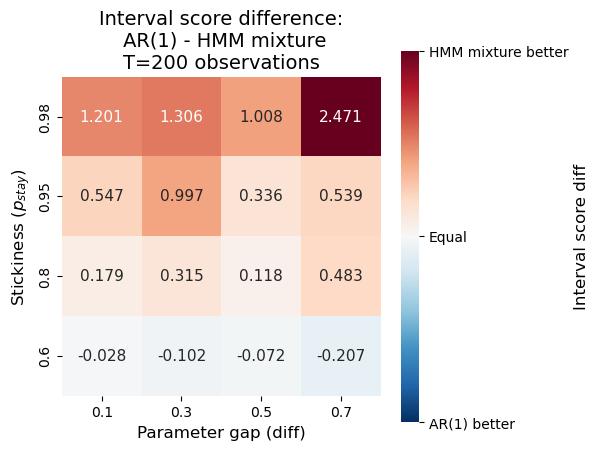

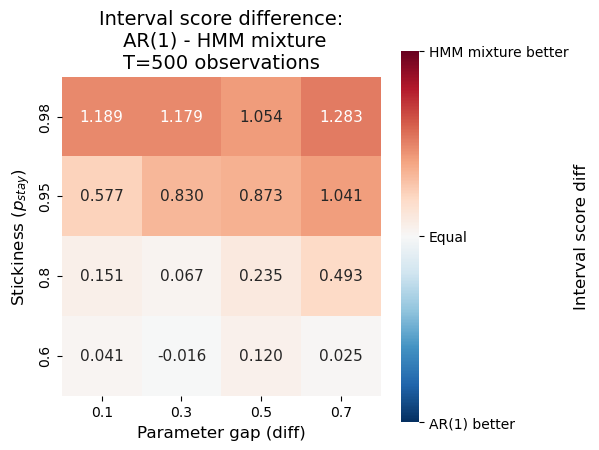

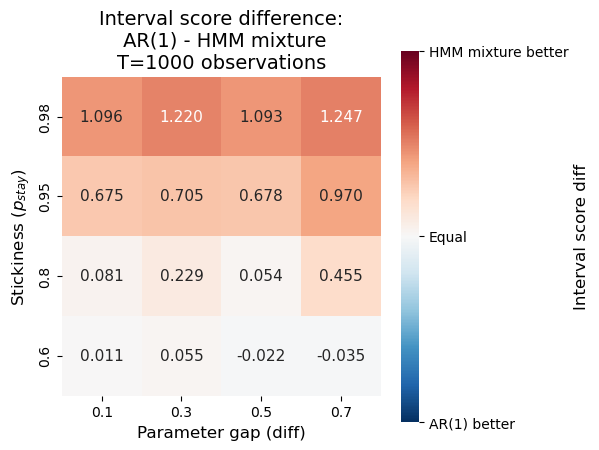

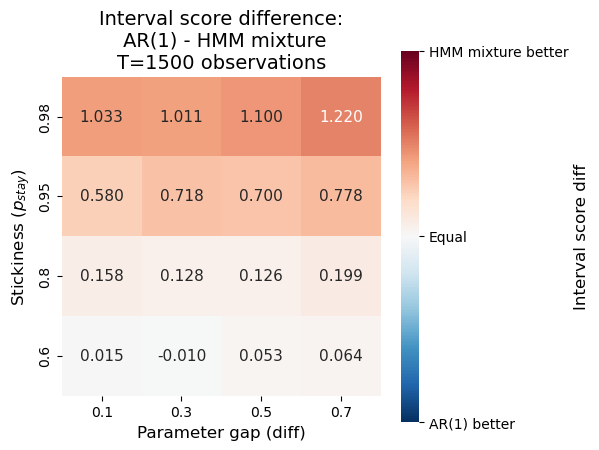

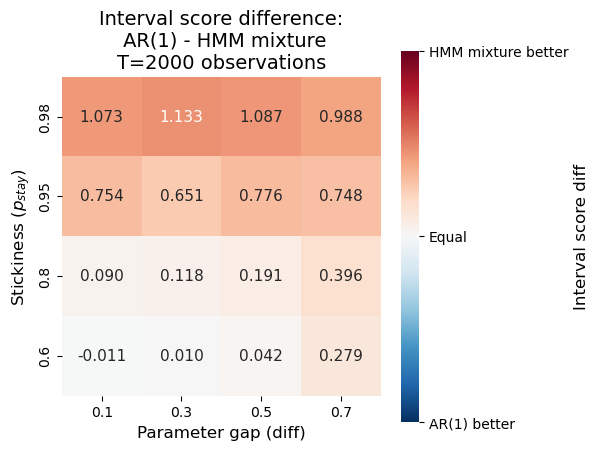

In [15]:
ar1_is = summary_df[summary_df["method"] == "AR1"][
    ["T", "diff", "p_stay", "interval_score_mean"]
].rename(columns={"interval_score_mean": "is_ar1"})

mix_is = summary_df[summary_df["method"] == "HMM_mixture"][
    ["T", "diff", "p_stay", "interval_score_mean"]
].rename(columns={"interval_score_mean": "is_mix"})

plot_df = ar1_is.merge(mix_is, on=["T", "diff", "p_stay"])
plot_df["is_diff"] = plot_df["is_ar1"] - plot_df["is_mix"]

max_abs = np.nanmax(np.abs(plot_df["is_diff"]))

for T in sorted(plot_df["T"].unique()):
    sub = plot_df[plot_df["T"] == T].pivot(
        index="p_stay", columns="diff", values="is_diff"
    ).sort_index(ascending=False)

    fig, ax = plt.subplots(figsize=(6, 5))

    hm = sns.heatmap(
        sub,
        ax=ax,
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
        center=0,
        annot=True,
        fmt=".3f",
        square=True,
        annot_kws={"size": 11},
        cbar_kws={"label": "Interval score diff"}
    )

    cbar = hm.collections[0].colorbar
    cbar.set_ticks([-max_abs, 0, max_abs])
    cbar.set_ticklabels(["AR(1) better", "Equal", "HMM mixture better"])

    ax.set_title(f"Interval score difference:\n AR(1) - HMM mixture\nT={T} observations")
    ax.set_xlabel("Parameter gap (diff)")
    ax.set_ylabel("Stickiness ($p_{{stay}}$)")

    plt.tight_layout()
    plt.savefig(f"../plots/interval_score_diff_mixture_T{T}.pdf", bbox_inches="tight")
    plt.show()


Hard Switch here:

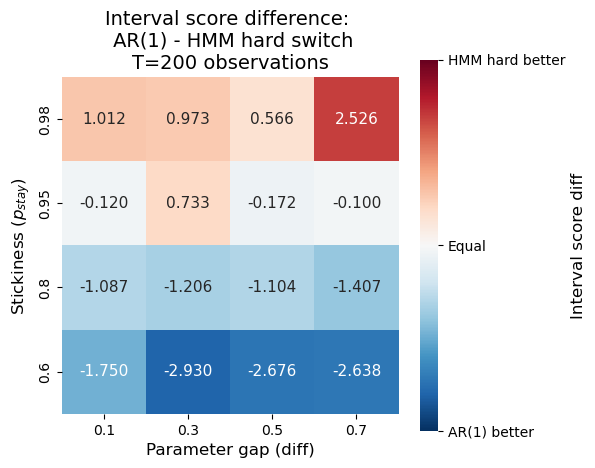

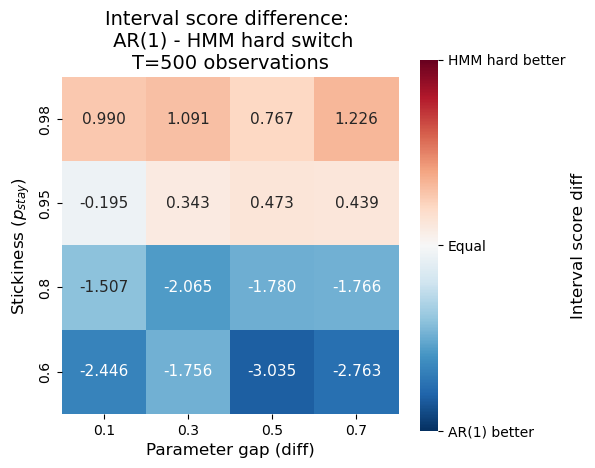

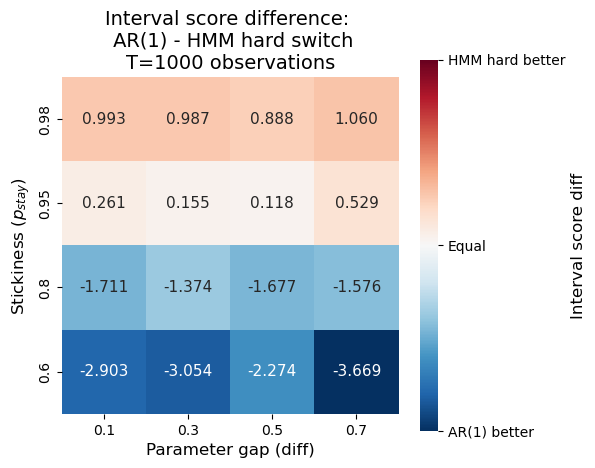

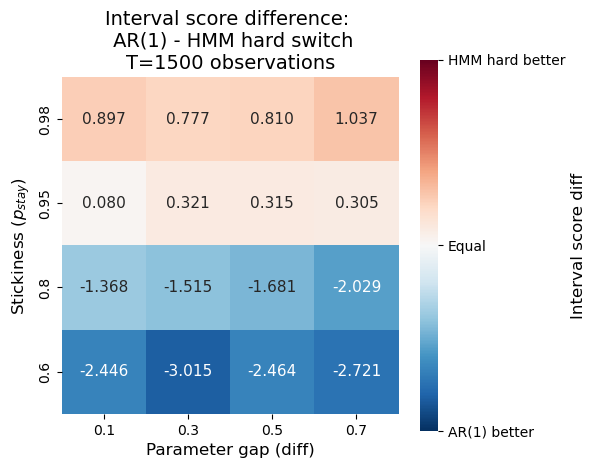

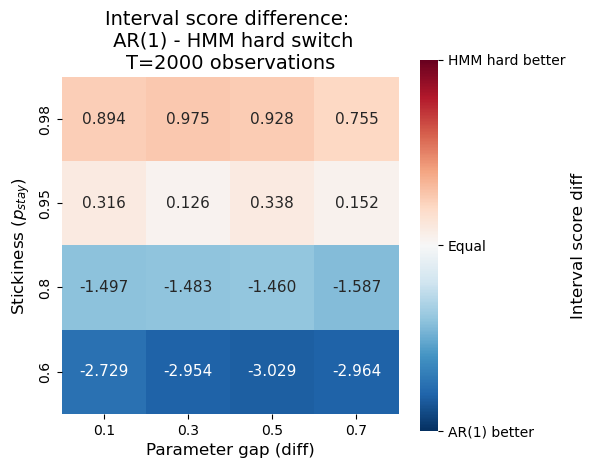

In [18]:
hard_is = summary_df[summary_df["method"] == "HMM_hard"][
    ["T", "diff", "p_stay", "interval_score_mean"]
].rename(columns={"interval_score_mean": "is_hard"})

plot_df_hard = ar1_is.merge(hard_is, on=["T", "diff", "p_stay"])
plot_df_hard["is_diff"] = plot_df_hard["is_ar1"] - plot_df_hard["is_hard"]

max_abs = np.nanmax(np.abs(plot_df_hard["is_diff"]))

for T in sorted(plot_df_hard["T"].unique()):
    sub = plot_df_hard[plot_df_hard["T"] == T].pivot(
        index="p_stay", columns="diff", values="is_diff"
    ).sort_index(ascending=False)

    fig, ax = plt.subplots(figsize=(6, 5))

    hm = sns.heatmap(
        sub,
        ax=ax,
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
        center=0,
        annot=True,
        fmt=".3f",
        square=True,
        annot_kws={"size": 11},
        cbar_kws={"label": "Interval score diff"}
    )

    cbar = hm.collections[0].colorbar
    cbar.set_ticks([-max_abs, 0, max_abs])
    cbar.set_ticklabels(["AR(1) better", "Equal", "HMM hard better"])

    ax.set_title(f"Interval score difference: \n AR(1) - HMM hard switch\nT={T} observations")
    ax.set_xlabel("Parameter gap (diff)")
    ax.set_ylabel("Stickiness ($p_{{stay}}$)")

    plt.tight_layout()
    plt.savefig(f"../plots/interval_score_diff_hard_T{T}.pdf", bbox_inches="tight")
    plt.show()


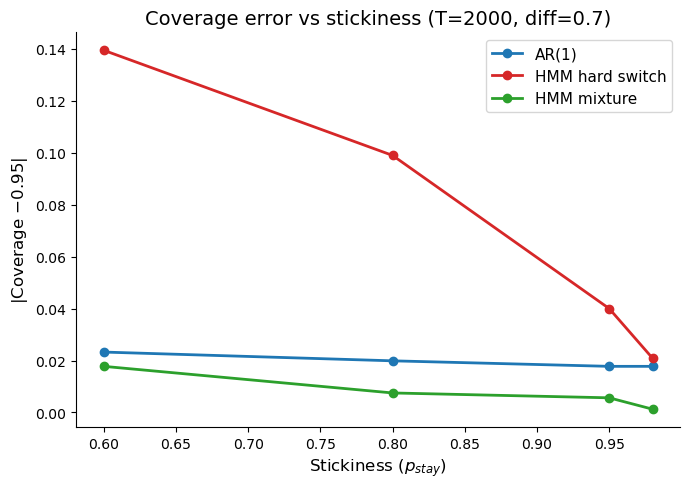

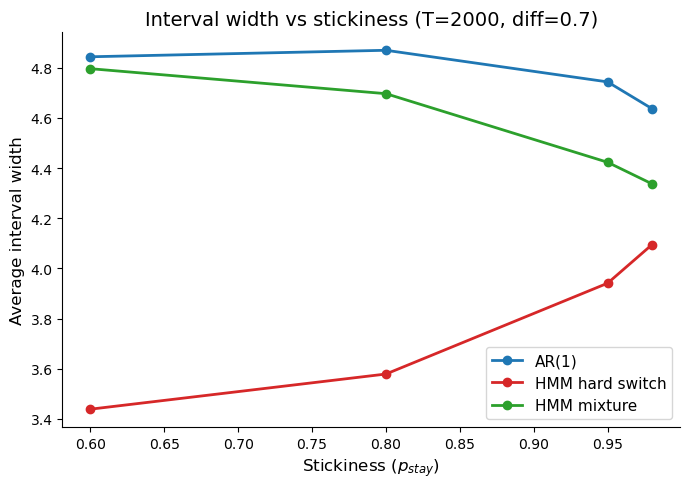

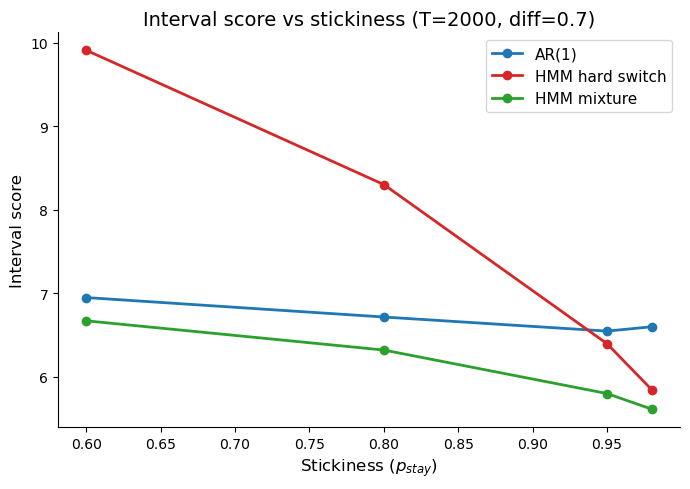

In [21]:
plot_df = summary_df.copy()
plot_df["coverage_error"] = np.abs(plot_df["coverage_mean"] - 0.95)

method_labels = {
    "AR1": "AR(1)",
    "HMM_hard": "HMM hard switch",
    "HMM_mixture": "HMM mixture"
}

palette = {
    "AR1": "#1f77b4",
    "HMM_hard": "#d62728",
    "HMM_mixture": "#2ca02c"
}

sub = plot_df[(plot_df["T"] == 2000) & (plot_df["diff"] == 0.7)]

figures = [
    ("coverage_error", r"$|$Coverage $- 0.95|$", "Coverage error vs stickiness (T=2000, diff=0.7)", "../plots/coverage_error_vs_stickiness.pdf"),
    ("avg_width_mean", "Average interval width", "Interval width vs stickiness (T=2000, diff=0.7)", "../plots/interval_width_vs_stickiness.pdf"),
    ("interval_score_mean", "Interval score", "Interval score vs stickiness (T=2000, diff=0.7)", "../plots/interval_score_vs_stickiness.pdf"),
]

for metric, ylabel, title, filename in figures:
    fig, ax = plt.subplots(figsize=(7, 5))
    for method in ["AR1", "HMM_hard", "HMM_mixture"]:
        tmp = sub[sub["method"] == method].sort_values("p_stay")
        ax.plot(tmp["p_stay"], tmp[metric], marker="o", linewidth=2,
                label=method_labels[method], color=palette[method])
    ax.set_title(title)
    ax.set_xlabel("Stickiness ($p_{stay}$)")
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()


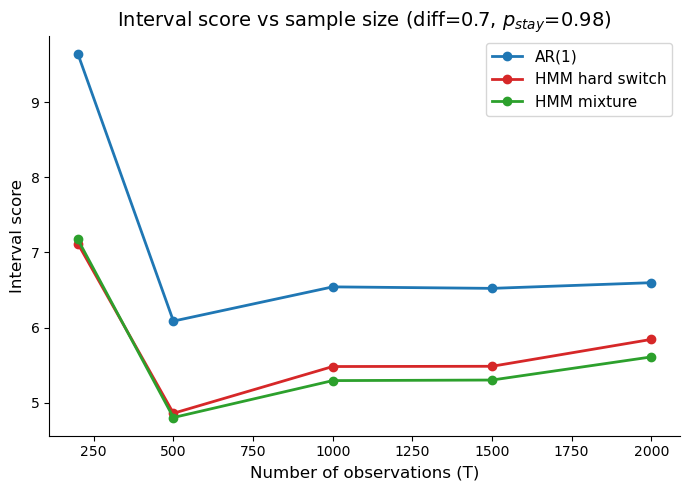

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

sub = plot_df[(plot_df["diff"] == 0.7) & (plot_df["p_stay"] == 0.98)]

for method in ["AR1", "HMM_hard", "HMM_mixture"]:
    tmp = sub[sub["method"] == method].sort_values("T")
    ax.plot(tmp["T"], tmp["interval_score_mean"], marker="o", linewidth=2,
            label=method_labels[method], color=palette[method])

ax.set_title("Interval score vs sample size (diff=0.7, $p_{stay}$=0.98)")
ax.set_xlabel("Number of observations (T)")
ax.set_ylabel("Interval score")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/interval_score_vs_sample_size.pdf", bbox_inches="tight")
plt.show()


### Prediction intervals on test data

One-step-ahead 95% prediction intervals for the three methods on the last 200 observations of a simulated 2-state HMM-AR(1) series (T=1000, β=[0.2, 0.7], σ=[0.5, 1.5], p_stay=0.95). Model fitted on the first 800 observations.


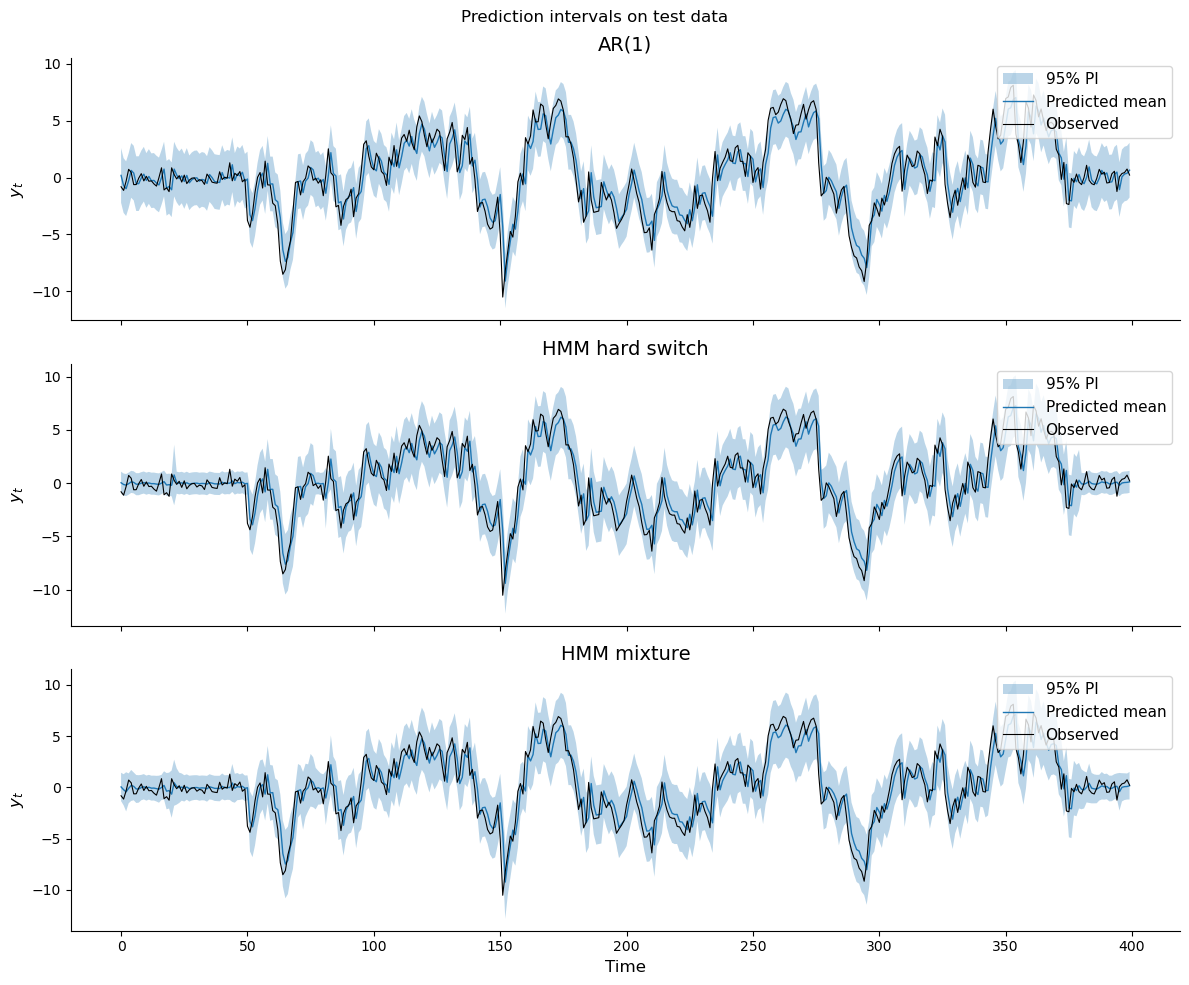

In [25]:
t_plot = range(len(y_test))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, (label, pred_mean, lower, upper) in zip(axes, [
    ("AR(1)", pred_mean_ar1, lower_ar1, upper_ar1),
    ("HMM hard switch", pred_mean_hard, lower_hard, upper_hard),
    ("HMM mixture", pred_mean_mix, lower_mix, upper_mix),
]):
    ax.fill_between(t_plot, lower, upper, alpha=0.3, label="95% PI")
    ax.plot(t_plot, pred_mean, linewidth=1, label="Predicted mean")
    ax.plot(t_plot, y_test, linewidth=0.8, color="black", label="Observed")
    ax.set_title(label)
    ax.set_ylabel("$y_t$")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time")
fig.suptitle("Prediction intervals on test data")
plt.tight_layout()
plt.savefig("../plots/prediction_intervals_example.pdf", bbox_inches="tight")
plt.show()
